# Project 2 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the Cats and Dogs data set (and maybe a subset of the MNIST data set).

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

In [295]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd 


# ------------------------------- big data
PATHIM1 = "cnd_large//images-1.csv" 
PATHIM2 = "cnd_large//images-2.csv" 
PATHLB = "cnd_large//labels.csv"

images1 = pd.read_csv(PATHIM1, sep=",", index_col=0)
images2 = pd.read_csv(PATHIM2, sep=",", index_col=0)
images = pd.concat([images1, images2])
# ------------------------------- big data


# ------------------------------- Smol dat
# PATHIM = ".//cnd_small//images.csv" 
# PATHLB = ".//cnd_small//labels.csv"

# images = pd.read_csv(PATHIM, sep=",", index_col=0)
# ------------------------------- Smol dat


labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


In [296]:
import matplotlib.pyplot as plt
import numpy as np



images = np.array(images)
labels = np.array(labels).ravel()

def visualize_samples(images, labels, n_samples=2, lasso_selected_img=None, kbest_selected_img=None):
    #Visualize some images (take two from each class):
    catidx = np.where(labels == 0)[0]
    dogidx = np.where(labels == 1)[0]

    n_samples = 2

    catsample = np.random.choice(catidx, size = n_samples, replace = False)
    dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

    idx = np.concatenate([catsample, dogsample])
    images_sub = images[idx]
    labels_sub = labels[idx]

    fig, axes = plt.subplots(2, 2)

    for i, ax in enumerate(axes.ravel()):
        img = images_sub[i].reshape(64,64)
        ax.imshow(img, cmap="gray")
        if lasso_selected_img is not None:
            lasso_mask = lasso_selected_img.reshape(64, 64)
            ax.imshow(np.ma.masked_where(lasso_mask == 0, lasso_mask), cmap="Reds", alpha=0.5, vmin=0, vmax=1)

        if kbest_selected_img is not None:
            kbest_mask = kbest_selected_img.reshape(64, 64)
            ax.imshow(np.ma.masked_where(kbest_mask == 0, kbest_mask), cmap="Blues", alpha=0.5, vmin=0, vmax=1)
        ax.set_title(f"Label: {labels_sub[i]}")
        ax.axis("off")

    plt.tight_layout()

In [297]:
# import numpy as np
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score

# X = images
# y = labels

# # Fixed train/test split
# X_train_full, X_test, y_train_full, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=y
# )

# n_train_full = X_train_full.shape[0]
# fractions = np.linspace(1.0, 0.1, 10)

# results = { "svd": [], "shrink": [] }
# rng = np.random.RandomState(0)

# for f in fractions:
#     n_keep = int(n_train_full * f)
#     idx = rng.choice(n_train_full, n_keep, replace=False)
#     X_train = X_train_full[idx]
#     y_train = y_train_full[idx]

#     # SVD solver (fastest)
#     try:
#         acc_svd = accuracy_score(y_test,
#             LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train).predict(X_test)
#         )
#     except:
#         acc_svd = np.nan

#     # Regularized / shrunk LDA (fast, avoids singularity)
#     try:
#         acc_shrink = accuracy_score(y_test,
#             LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
#             .fit(X_train, y_train)
#             .predict(X_test)
#         )
#     except:
#         acc_shrink = np.nan

#     results["svd"].append((f, acc_svd))
#     results["shrink"].append((f, acc_shrink))

# # Print
# for name in results:
#     print(f"\n== {name} ==")
#     for f, acc in results[name]:
#         print(f"Fraction {f:.2f}: acc = {acc:.3f}")

# Part 1

*Everyone should do this task.*

For the first part, use the provided Cats and Dogs data set.

Use at least 3 different classifiers and at least 2 feature selection methods.

For example, you can use filtering or wrappers in conjuction with any of the classifiers (using e.g. threshholds on the importance, t-tests/F-tests or CV-error with forward selection etc). I.e., for the filtering method you choose a test or scoring mechanism and use CV to determine the optimal threshold.

For the wrapper method you choose, e.g., forward selection or backward selection, CV is used when to stop adding features. Here, the scoring mechanism to decide which order to drop/add features can be based on drop/increase in predictive performance, importance metrics, etc.

The embedding methods we have talked about in class is lasso/elastic net which is used with multinomial/logistic regression. For the embedding methods, CV is used to choose the penalty parameter.

Note, you can also use a combination of techniques - perhaps you want to filter the features before you use wrappers or embedding methods?

Questions to answer

1. Using CV, determine how many features (pixels) you need for classification. Does the optimal number of features differ between the approaches?

2. Which pixels are selected? Does this differ between the approaches/classification methods? (Can you think of why?)

3. Repeat the above a few times - is the selection stable? (meaning the number of features needed and/or which pixels are chosen is roughly the same across multiple runs).



In [298]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Lasso

X = images
y = labels

# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Classifier
# clf = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=7)
svm = SVC(C=10, kernel="rbf", gamma="scale")
rf = RandomForestClassifier(n_estimators=100, max_depth=20)
# mlp = MLPClassifier([32, 64, 32])

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)




In [299]:
def kBest_feature_selection(X_train_full, y_train_full):
    # Filtering
    selector = SelectKBest(f_classif, k=800).fit(X_train_full, y_train_full)
    X_small = selector.transform(X_train_full)
    print("Filter done")

    selected_indices = selector.get_support(indices=True)
    selected_img = np.zeros(4096)
    selected_img[selected_indices] = 1


    scores = cross_val_score(knn, X_small, y_train_full, cv=cv)
    print("Knn accuracy:", scores.mean())

    scores = cross_val_score(svm, X_small, y_train_full, cv=cv)
    print("SVM accuracy:", scores.mean())

    scores = cross_val_score(rf, X_small, y_train_full, cv=cv)
    print("rf accuracy:", scores.mean())

    # scores = cross_val_score(mlp, X_small, y_train_full, cv=cv)
    # print("mlp accuracy:", scores.mean())

    return selected_img

selected_img = kBest_feature_selection(X_train_full, y_train_full)


Filter done
Knn accuracy: 0.7725555555555556
SVM accuracy: 0.8867777777777779
rf accuracy: 0.8463333333333333


In [300]:

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

def lasso_feature_selection(X_train_full, y_train_full):
    # Lasso requires scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train_full)

    lasso = Lasso(alpha=0.005, max_iter=5000)
    lasso.fit(X_scaled, y_train_full)

    selected = np.where(lasso.coef_ != 0)[0]
    print("Lasso selected features:", len(selected))

    lasso_selected_img = np.zeros(4096)
    lasso_selected_img[selected] = 1

    # Reduce dataset
    X_lasso = X_train_full[:, selected]

    # -----------------------------
    # Evaluate classifiers on Lasso-selected features
    # -----------------------------
    scores = cross_val_score(knn, X_lasso, y_train_full, cv=cv)
    print("KNN (Lasso features):", scores.mean())

    scores = cross_val_score(svm, X_lasso, y_train_full, cv=cv)
    print("SVM (Lasso features):", scores.mean())

    scores = cross_val_score(rf, X_lasso, y_train_full, cv=cv)
    print("RF (Lasso features):", scores.mean())

    # scores = cross_val_score(mlp, X_lasso, y_train_full, cv=cv)
    # print("MLP (Lasso features):", scores.mean())

    return lasso_selected_img


lasso_selected_img = lasso_feature_selection(X_train_full, y_train_full)

Lasso selected features: 285
KNN (Lasso features): 0.8127777777777778
SVM (Lasso features): 0.9082222222222223
RF (Lasso features): 0.8685555555555556


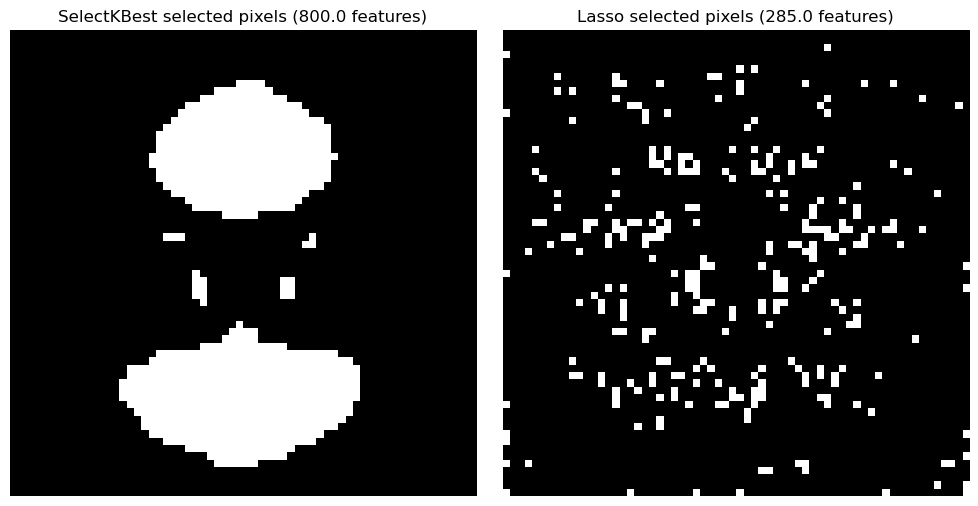

In [301]:
def plot_selected_pixels(selected_img, lasso_selected_img):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(selected_img.reshape(64, 64), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"SelectKBest selected pixels ({selected_img.sum()} features)")
    axes[0].axis("off")

    axes[1].imshow(lasso_selected_img.reshape(64, 64), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Lasso selected pixels ({lasso_selected_img.sum()} features)")
    axes[1].axis("off")

    plt.tight_layout()

plot_selected_pixels(selected_img, lasso_selected_img)

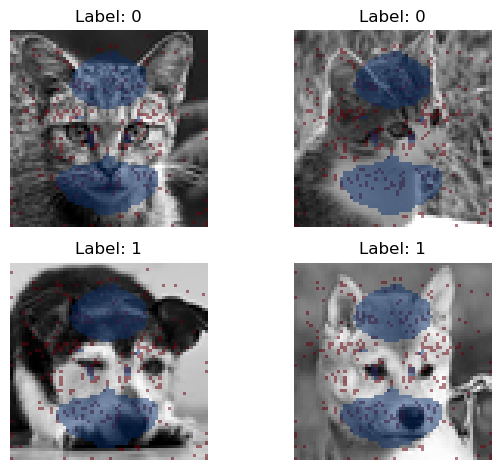

In [302]:
visualize_samples(X_train_full, y_train_full, lasso_selected_img=lasso_selected_img, kbest_selected_img=selected_img)

## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Correlated noise features
Use the Cats and Dogs data set. 

Add (independent) Gaussian noise to a subset of the features. Increase the percentage of the features. 
How is classification accuracy affected for the different methods?

Now, do the same but with correlated Gaussian noise. 
How do the different methods handle correlated noise features? 
At what noise level do the methods break down? 

### Theme 2 - Image flip
Use the Cats and Dogs data set. 

Flip half of the images (half of the cats and half of the dogs) upside down. 
Perform the same steps as in Part 1. 

How is feature importance affected by the flipping?

### Theme 3 - Heterogeneous classes
Use the MNIST data set. 

Create heterogeneous classes by flipping half of the images in a class. 
1. First, flip images in class 0.
2. Then, flip images in class 4 (and revert the changes from the previous step).
3. Lastly, flip images in one of class 2, 5, 6 or 9 (and revert the changes from the previous step).

Perform the same steps as in Part 1 for the three sets. 

Present confusion matrices and other appropriate plots. What happened? 

## Flip some images

In [303]:
flip_split = 0.5

index0 = np.where(y_train_full == 0)[0]
index1 = np.where(y_train_full == 1)[0]

half_cats = np.random.choice(index0, size=int(len(index0)*flip_split), replace=False)
half_dogs = np.random.choice(index1, size=int(len(index1)*flip_split), replace=False)

to_flip = np.concatenate([half_cats, half_dogs])

X_flipped = X_train_full.copy()

for i in to_flip:
    X_flipped[i] = np.flipud(images[i].reshape(64,64)).flatten()

KBest: --------------------------------------------------
Filter done
Knn accuracy: 0.6186666666666667
SVM accuracy: 0.6721111111111111
rf accuracy: 0.6657777777777778

Lasso: --------------------------------------------------
Lasso selected features: 211
KNN (Lasso features): 0.6293333333333333
SVM (Lasso features): 0.6821111111111111
RF (Lasso features): 0.6765555555555556


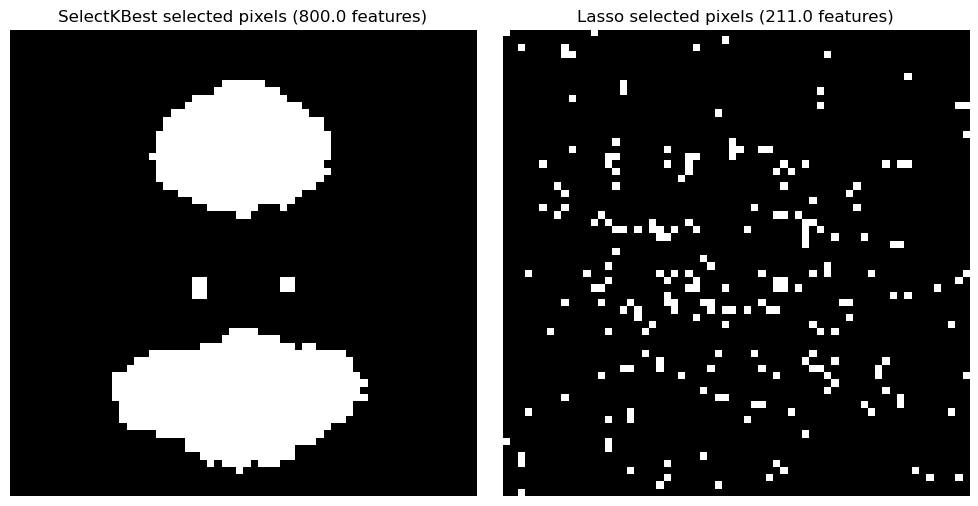

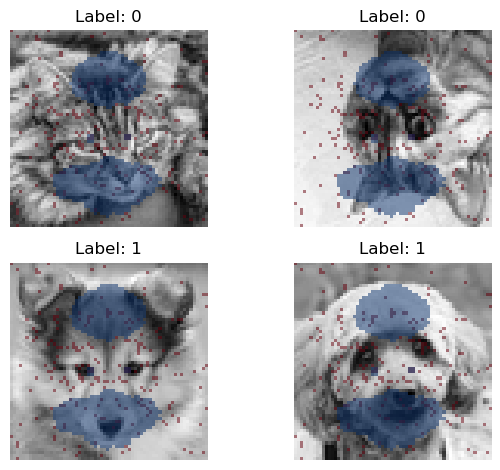

In [304]:
print("KBest: --------------------------------------------------")
flipped_selected_img = kBest_feature_selection(X_flipped, y_train_full)

print("\nLasso: --------------------------------------------------")
flipped_lasso_selected_img = lasso_feature_selection(X_flipped, y_train_full)

plot_selected_pixels(flipped_selected_img, flipped_lasso_selected_img)

visualize_samples(X_flipped, y_train_full, lasso_selected_img=flipped_lasso_selected_img, kbest_selected_img=flipped_selected_img)
